# Chapter 3: Statistical Experiments and Significance Testing

## 1. Summary / Ringkasan Bab
Bab ini membahas metode eksperimen statistik yang digunakan untuk menguji hipotesis dan mengambil keputusan berbasis data. Fokus utamanya mencakup Pengujian A/B (A/B Testing), Uji Permutasi (Permutation Test), Signifikansi Statistik, p-value, t-Test, ANOVA (Analysis of Variance), dan Uji Chi-Square.

## 2. Theoretical Deep-Dive
- **A/B Testing & Hypothesis Testing**:
  - *A/B Testing*: Eksperimen dua kelompok (A sebagai kontrol, B sebagai perlakuan) untuk membandingkan perbedaan performa (misal: tingkat konversi halaman web).
  - *Null Hypothesis ($H_0$)*: Asumsi dasar bahwa tidak ada perbedaan efek antara dua kelompok.
  - *Alternative Hypothesis ($H_a$)*: Hipotesis yang ingin dibuktikan (terdapat perbedaan signifikan).
- **p-value & Statistical Significance**:
  - *p-value*: Probabilitas mendapatkan hasil se-ekstrem atau lebih ekstrem dari sampel yang diamati, dengan asumsi $H_0$ benar. Jika p-value < $\alpha$ (biasanya 0.05), $H_0$ ditolak.
  - *Alpha ($\alpha$)*: Tingkat signifikansi (ambang batas toleransi kesalahan Tipe I).
- **t-Test, ANOVA, & Chi-Square**:
  - *t-Test*: Membandingkan rata-rata dari dua kelompok numerik.
  - *ANOVA*: Membandingkan rata-rata dari tiga atau lebih kelompok numerik sekaligus.
  - *Chi-Square Test*: Menguji independensi/hubungan antara dua variabel kategorik.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Simulasi A/B Testing & Permutation Test
np.random.seed(42)

# Data tingkat konversi Web A (Kontrol) vs Web B (Variasi)
group_A = np.random.binomial(n=1, p=0.05, size=1000)  # Conversion rate ~5%
group_B = np.random.binomial(n=1, p=0.08, size=1000)  # Conversion rate ~8%

mean_A = np.mean(group_A)
mean_B = np.mean(group_B)
observed_diff = mean_B - mean_A

print("=== A/B TESTING DESCRIPTIVE RESULTS ===")
print(f"Group A Conversion Rate: {mean_A*100:.2f}%")
print(f"Group B Conversion Rate: {mean_B*100:.2f}%")
print(f"Observed Difference    : {observed_diff*100:.2f}%\n")

# Permutation Test (Resampling untuk A/B Test)
combined = np.concatenate([group_A, group_B])
perm_diffs = []

for _ in range(2000):
    np.random.shuffle(combined)
    perm_A = combined[:len(group_A)]
    perm_B = combined[len(group_A):]
    perm_diffs.append(np.mean(perm_B) - np.mean(perm_A))

p_value_perm = np.mean(np.array(perm_diffs) >= observed_diff)
print(f"Permutation Test p-value: {p_value_perm:.4f}")

=== A/B TESTING DESCRIPTIVE RESULTS ===
Group A Conversion Rate: 4.60%
Group B Conversion Rate: 8.90%
Observed Difference    : 4.30%

Permutation Test p-value: 0.0000


In [2]:
# 2. t-Test (Dua Kelompok Numerik)
t_stat, p_val_ttest = stats.ttest_ind(group_B, group_A)

print("=== TWO-SAMPLE T-TEST RESULTS ===")
print(f"t-Statistic : {t_stat:.4f}")
print(f"p-value     : {p_val_ttest:.4f}")

if p_val_ttest < 0.05:
    print("Kesimpulan  : Tolak H0 (Perbedaan signifikan secara statistik)\n")
else:
    print("Kesimpulan  : Gagal Tolak H0 (Tidak ada perbedaan signifikan)\n")

# 3. ANOVA (Tiga Kelompok)
group_C = np.random.binomial(n=1, p=0.06, size=1000)
f_stat, p_val_anova = stats.f_oneway(group_A, group_B, group_C)

print("=== ONE-WAY ANOVA RESULTS ===")
print(f"F-Statistic : {f_stat:.4f}")
print(f"p-value     : {p_val_anova:.4f}\n")

# 4. Chi-Square Test (Variabel Kategorik)
contingency_table = pd.DataFrame({
    'Converted': [sum(group_A), sum(group_B)],
    'Not_Converted': [len(group_A) - sum(group_A), len(group_B) - sum(group_B)]
}, index=['Group_A', 'Group_B'])

chi2_stat, p_val_chi2, dof, ex = stats.chi2_contingency(contingency_table)

print("=== CHI-SQUARE TEST RESULTS ===")
print(contingency_table)
print(f"\nChi2 Statistic : {chi2_stat:.4f}")
print(f"p-value        : {p_val_chi2:.4f}")

=== TWO-SAMPLE T-TEST RESULTS ===
t-Statistic : 3.8447
p-value     : 0.0001
Kesimpulan  : Tolak H0 (Perbedaan signifikan secara statistik)

=== ONE-WAY ANOVA RESULTS ===
F-Statistic : 7.5600
p-value     : 0.0005

=== CHI-SQUARE TEST RESULTS ===
         Converted  Not_Converted
Group_A         46            954
Group_B         89            911

Chi2 Statistic : 14.0125
p-value        : 0.0002


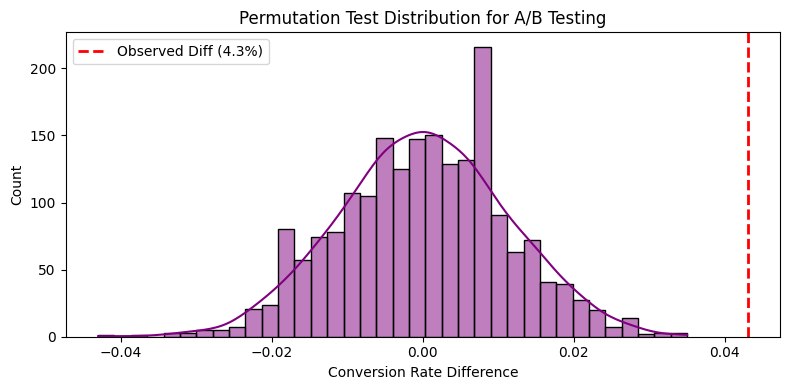

In [3]:
# Visualisasi Distribusi Permutation Test
plt.figure(figsize=(8, 4))
sns.histplot(perm_diffs, kde=True, color='purple')
plt.axvline(observed_diff, color='red', linestyle='--', linewidth=2, label=f'Observed Diff ({observed_diff*100:.1f}%)')
plt.title('Permutation Test Distribution for A/B Testing')
plt.xlabel('Conversion Rate Difference')
plt.legend()
plt.tight_layout()
plt.show()